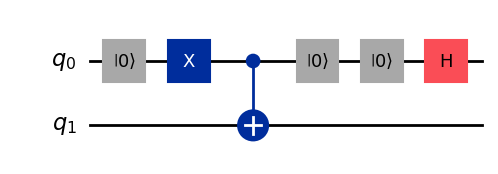

In [1]:
from qiskit import QuantumCircuit, transpile

qc = QuantumCircuit(2)
qc.reset(0)
qc.x(0)
qc.cx(0, 1)
qc.reset(0)
qc.reset(0)
qc.h(0)
qc.draw(output="mpl")

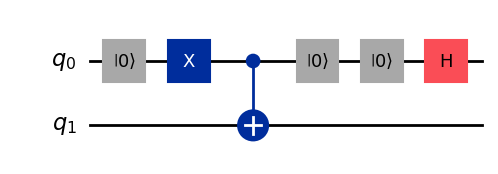

In [2]:
qc_basic_transpile = transpile(qc, optimization_level=3)
qc_basic_transpile.draw(output="mpl", style="iqp")

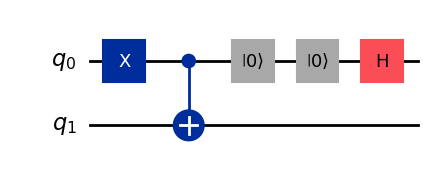

In [3]:
from qiskit.transpiler.passes.optimization.remove_reset_in_zero_state import (
    RemoveResetInZeroState,
)
from qiskit.converters import circuit_to_dag, dag_to_circuit

remove_reset = RemoveResetInZeroState()
remove_reset(qc).draw("mpl")

In [7]:
from qiskit.transpiler.basepasses import AnalysisPass


class CollectResets(AnalysisPass):
    """A local recreation of the dynacir helper pass to track reset operations."""

    def __init__(self):
        super().__init__()

    def run(self, dag):
        # We look at the Directed Acyclic Graph (DAG) representation of the circuit
        # and store the nodes containing reset instructions in the property set
        self.property_set["resets"] = dag.reset_nodes()
        return dag


# Now instantiate it exactly like the tutorial does
collect_resets = CollectResets()
print("Successfully initialized local CollectResets pass structure!")

Successfully initialized local CollectResets pass structure!
